In [1]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti
import tqdm

ti.init(arch=ti.cpu)

[Taichi] version 1.7.4, llvm 15.0.1, commit b4b956fd, win, python 3.13.5
[Taichi] Starting on arch=x64


In [2]:
N_nodes = 10
N_bonds = N_nodes - 1

a = 1.0
m = 1.0              
k = 100.0            
ko = 100.0          
fmax = 0.1 * ko * a  
damping_ratio = 0.05
eta = 2.0 * np.sqrt(k * m) * damping_ratio
mu = 0.0

amp = 1e-2
omega = np.sqrt(k / m)
periodicity = 2.0 * np.pi / omega
t_step = 50
dt = periodicity / t_step

total_step = 4000

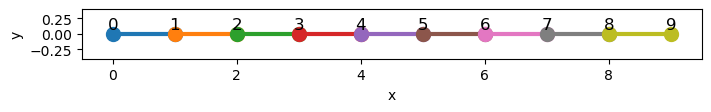

In [3]:
nodes_np = np.array([[i * a, 0.0] for i in range(N_nodes)], dtype=np.float32)
vel_np = np.zeros((N_nodes, 2), dtype=np.float32)

bonds_np = np.array([[i, i + 1] for i in range(N_bonds)], dtype=np.int32)
rest_length_np = np.full(N_bonds, a, dtype=np.float32)


fig, ax = plt.subplots(figsize=(max(6, N_nodes * 0.8), 2))
for i, j in bonds_np:
    ax.plot(
        [nodes_np[i, 0], nodes_np[j, 0]],
        [nodes_np[i, 1], nodes_np[j, 1]],
        "-o",
        linewidth=3,
        markersize=10,
    )

for i in range(N_nodes):
    ax.text(
        nodes_np[i, 0],
        nodes_np[i, 1] + 0.08,
        f"{i}",
        ha="center",
        fontsize=12,
    )

ax.set_aspect("equal")
ax.set_xlim(-0.5 * a, (N_nodes - 0.5) * a)
ax.set_ylim(-0.4 * a, 0.4 * a)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(False)

plt.show()



In [4]:
pos = ti.Vector.field(2, dtype=ti.f32, shape=N_nodes)
vel = ti.Vector.field(2, dtype=ti.f32, shape=N_nodes)
force = ti.Vector.field(2, dtype=ti.f32, shape=N_nodes)

bonds = ti.Vector.field(2, dtype=ti.i32, shape=N_bonds)
rest_length = ti.field(dtype=ti.f32, shape=N_bonds)
extension = ti.field(dtype=ti.f32, shape=N_bonds)
tension = ti.field(dtype=ti.f32, shape=N_bonds)

pos_record = ti.Vector.field(2, dtype=ti.f32, shape=(total_step, N_nodes))
vel_record = ti.Vector.field(2, dtype=ti.f32, shape=(total_step, N_nodes))
extension_record = ti.field(dtype=ti.f32, shape=(total_step, N_bonds))
tension_record = ti.field(dtype=ti.f32, shape=(total_step, N_bonds))

pos.from_numpy(nodes_np)
vel.from_numpy(vel_np)
bonds.from_numpy(bonds_np)
rest_length.from_numpy(rest_length_np)

def pertubation(amp_value=amp):
    global nodes_np, vel_np
    nodes_np = np.array([[i * a, 0.0] for i in range(N_nodes)], dtype=np.float32)
    
    middle_index = N_nodes // 2
    nodes_np[middle_index, 0] += amp_value
    
    vel_np = np.zeros((N_nodes, 2), dtype=np.float32)
    pos.from_numpy(nodes_np)
    vel.from_numpy(vel_np)

@ti.func
def clamp(x, xmin, xmax):
    return ti.min(ti.max(x, xmin), xmax)

@ti.kernel
def zero_force():
    for i in range(N_nodes):
        force[i] = ti.Vector([0.0, 0.0])

@ti.kernel
def nodal_f_passive():
    for b in range(N_bonds):
        i = bonds[b][0]
        j = bonds[b][1]

        rij = pos[j] - pos[i]
        lij = rij.norm()

        if lij > 1e-8:
            eij = rij / lij
            dl = lij - rest_length[b]
            extension[b] = dl

            vij = vel[j] - vel[i]
            dl_dt = vij.dot(eij)

            T = k * dl + eta * dl_dt
            tension[b] = T

            force[i] += T * eij
            force[j] -= T * eij

@ti.func
def apply_bond_tension(b: ti.i32, T: ti.f32):
    i = bonds[b][0]
    j = bonds[b][1]
    r = pos[j] - pos[i]
    e = r / r.norm()
    force[i] += T * e
    force[j] -= T * e

@ti.kernel
def nodal_f_active():

    for b in range(N_bonds - 1):
        d1 = extension[b]
        d2 = extension[b + 1]

        T1 = clamp(ko * d2, -fmax, fmax)
        T2 = clamp(-ko * d1, -fmax, fmax)

        tension[b] += T1
        tension[b + 1] += T2

        apply_bond_tension(b, T1)
        apply_bond_tension(b + 1, T2)

@ti.kernel
def update():
    for i in range(N_nodes):
        force[i] += -mu * vel[i]
        vel[i] += dt * force[i] / m
        pos[i] += dt * vel[i]

@ti.kernel
def data_record(frame: ti.i32):
    for i in range(N_nodes):
        pos_record[frame, i] = pos[i]
        vel_record[frame, i] = vel[i]
    for b in range(N_bonds):
        extension_record[frame, b] = extension[b]
        tension_record[frame, b] = tension[b]


In [5]:
pertubation(amp_value=amp*10)

zero_force()
nodal_f_passive()
nodal_f_active()
data_record(0)

for ii in tqdm.tqdm(range(total_step - 1), desc="Simulating"):
    zero_force()
    nodal_f_passive()
    nodal_f_active()
    update()
    data_record(ii + 1)

Simulating: 100%|██████████| 3999/3999 [00:02<00:00, 1839.74it/s]


In [6]:

bonds_ti = ti.field(dtype=ti.i32, shape=N_bonds * 2)
bonds_ti.from_numpy(bonds_np.flatten().astype(np.int32))

pos_render = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)


def set_render_pos(frame_2d):
    frame_3d = np.zeros((N_nodes, 3), dtype=np.float32)
    frame_3d[:, 0] = frame_2d[:, 0]   # x
    frame_3d[:, 1] = frame_2d[:, 1]   # y
    frame_3d[:, 2] = 0.0              # z = 0
    pos_render.from_numpy(frame_3d)


def video(plt_step=1, close=1, save=0):
    pos_np = pos_record.to_numpy()[::plt_step]
    N_step = len(pos_np)

    window = ti.ui.Window(
        f"{N_nodes}-node odd model: ko={ko}",
        (800, 450),
        vsync=True,
        fps_limit=60,
        pos=(0, 150),
    )

    canvas = window.get_canvas()
    canvas.set_background_color((1, 1, 1))

    scene = window.get_scene()
    camera = ti.ui.Camera()
    gui = window.get_gui()

    center_x = (N_nodes * a) / 2.0
    camera_z = max(4.0, N_nodes * 0.8) 
    
    camera.position(center_x, 1.0, camera_z)
    camera.lookat(center_x, 0.0, 0.0)
    camera.up(0.0, 1.0, 0.0)

    pause = False
    step = 0

    while window.running:
        camera.track_user_inputs(window, movement_speed=0.05, hold_key=ti.ui.RMB)
        scene.set_camera(camera)

        scene.ambient_light((0.6, 0.6, 0.6))
        scene.point_light(pos=(2.0, 2.0, 4.0), color=(1, 1, 1))

        for e in window.get_events(ti.ui.PRESS):
            if e.key == ti.ui.ESCAPE:
                window.running = False
            elif e.key == ti.ui.SPACE:
                pause = not pause

        if window.is_pressed("r"):
            step = 0
        if window.is_pressed("z"):
            step += 10
        if window.is_pressed("x"):
            step -= 10

        step = max(0, min(step, N_step - 1))

        with gui.sub_window("Simulation", 0.00, 0.88, 0.45, 0.12) as w:
            w.text(f"frame: {step}/{N_step - 1}")
            w.text(f"physical step: {step * plt_step * t_step}")

        # initial configuration: gray
        set_render_pos(pos_np[0])
        scene.lines(
            vertices=pos_render,
            indices=bonds_ti,
            color=(0.55, 0.55, 0.55),
            width=2.0,
        )

        # current configuration: black bonds
        set_render_pos(pos_np[step])
        scene.lines(
            vertices=pos_render,
            indices=bonds_ti,
            color=(0.0, 0.0, 0.0),
            width=8.0,
        )

        # current nodes
        scene.particles(
            pos_render,
            radius=0.045 * a,
            color=(0.1, 0.2, 0.9),
        )

        # trajectory tails
        tail_num = 10
        tail_gap = 2

        for i in range(tail_num):
            step_i = step - i * tail_gap
            if step_i >= 0:
                set_render_pos(pos_np[step_i])
                scene.particles(
                    pos_render,
                    radius=0.035 * a * (1.0 - 0.05 * i),
                    color=(0.2 + 0.05 * i, 0.2 + 0.05 * i, 1.0),
                )

        canvas.scene(scene)
        window.show()

        if not pause:
            step += 1

        if step >= N_step:
            if close == 1:
                window.running = False
            else:
                step = N_step - 1
                pause = True
video(plt_step=1, close=0)